# Моделирование поведения питомца (марковский и полумарковский процессы)

В данной модели мы используем 5 состояний.
Переходы между состояниями определяются интенсивностями ($\lambda$).

Чтобы сделать поведение более реалистичным и уменьшить случайные выбросы (например, сон по 1 минуте), для генерации времени ($\tau$) вместо классического экспоненциального используется **распределение Эрланга k-го порядка**.
Формула генерации:
$$ \tau = -\frac{1}{k \cdot \lambda} \ln \left( \prod_{i=1}^{k} r_i \right) $$
где $k$ выбирает пользователь (когда значение 1 - это классический марковский процесс), а $r_i$ — независимые случайные величины от 0 до 1.
Метод конкурирующих рисков сохраняется: питомец выбирает то событие, $\tau$ которого наступит раньше.


### Ячейка 1. Настройки, состояния и лямбды

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(402) # Фиксируем для воспроизводимости
K = 10
# Матрица интенсивностей переходов (лямбд).
transition_rates = {
    'Сон':    {'Еда': 0.15, 'Туалет': 0.05, 'Отдых': 0.1},
    'Еда':    {'Туалет': 3.0,  'Отдых': 2.0},
    'Туалет': {'Отдых': 5.0,   'Игра': 2.0},
    'Отдых':  {'Сон': 0.5,     'Игра': 0.5,   'Еда': 0.2},
    'Игра':   {'Отдых': 1.0,   'Еда': 1.5,    'Сон': 0.5}
}

states = list(transition_rates.keys())
y_levels = {'Сон': 1, 'Отдых': 2, 'Игра': 3, 'Еда': 4, 'Туалет': 5}

# Уникальные цвета для состояний
colors = {
    'Сон': '#1f77b4',     # Синий
    'Отдых': '#a9a9a9',   # Серый
    'Игра': '#ff7f0e',    # Оранжевый
    'Еда': '#2ca02c',     # Зеленый
    'Туалет': '#d62728'   # Красный
}


### Ячейка 2. Отрисовка графа

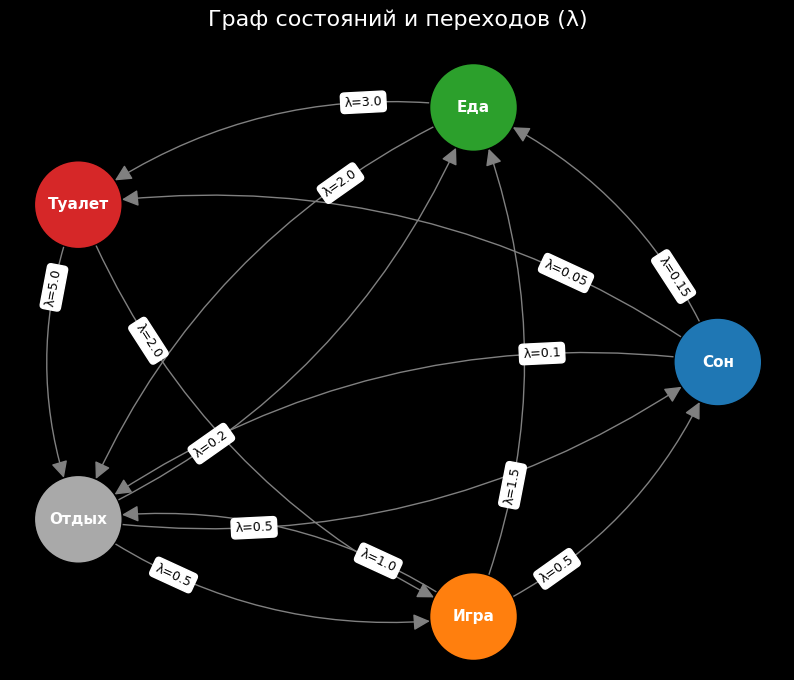

In [48]:
G = nx.DiGraph()

for u, edges in transition_rates.items():
    for v, rate in edges.items():
        G.add_edge(u, v, weight=rate)

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(G)

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_size=4000, node_color=[colors[n] for n in G.nodes()], edgecolors='black')

# Рисуем изогнутые ребра (connectionstyle="arc3,rad=0.2"), чтобы они не шли через центр
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=25,
                       connectionstyle="arc3,rad=0.2", node_size=4000)

nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold", font_color="white")

# Подписи к ребрам (лямбды)
edge_labels = {(u, v): f"λ={d['weight']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, label_pos=0.25,
                             connectionstyle="arc3,rad=0.2")

plt.title("Граф состояний и переходов (λ)", fontsize=16, pad=20)
plt.axis('off')
plt.show()

### Ячейка 3. Движок симуляции

In [49]:
def simulate_pet_erlang(max_hours=24, k=K):
    """
    Симулирует поведение питомца с использованием распределения Эрланга k-го порядка.
    """
    current_time = 0.0
    current_state = 'Сон'
    history = []

    while current_time < max_hours:
        possible_transitions = transition_rates[current_state]

        competing_events = {}
        for next_state, lambda_val in possible_transitions.items():
            # Генерируем k случайных чисел от 0 до 1
            r_array = np.random.uniform(0, 1, k)

            # Формула Эрланга k-го порядка с сохранением математического ожидания
            tau = (-1.0 / (k * lambda_val)) * np.log(np.prod(r_array))
            competing_events[next_state] = tau

        # Событие с минимальным временем побеждает (конкурирующие риски)
        next_state = min(competing_events, key=competing_events.get)
        time_in_state = competing_events[next_state]
        end_time = current_time + time_in_state

        if end_time > max_hours:
            history.append((current_time, max_hours, current_state))
            break

        history.append((current_time, end_time, current_state))

        current_time = end_time
        current_state = next_state

    return history

### Ячейка 4. Расписание состояний и переходов (24 часа)

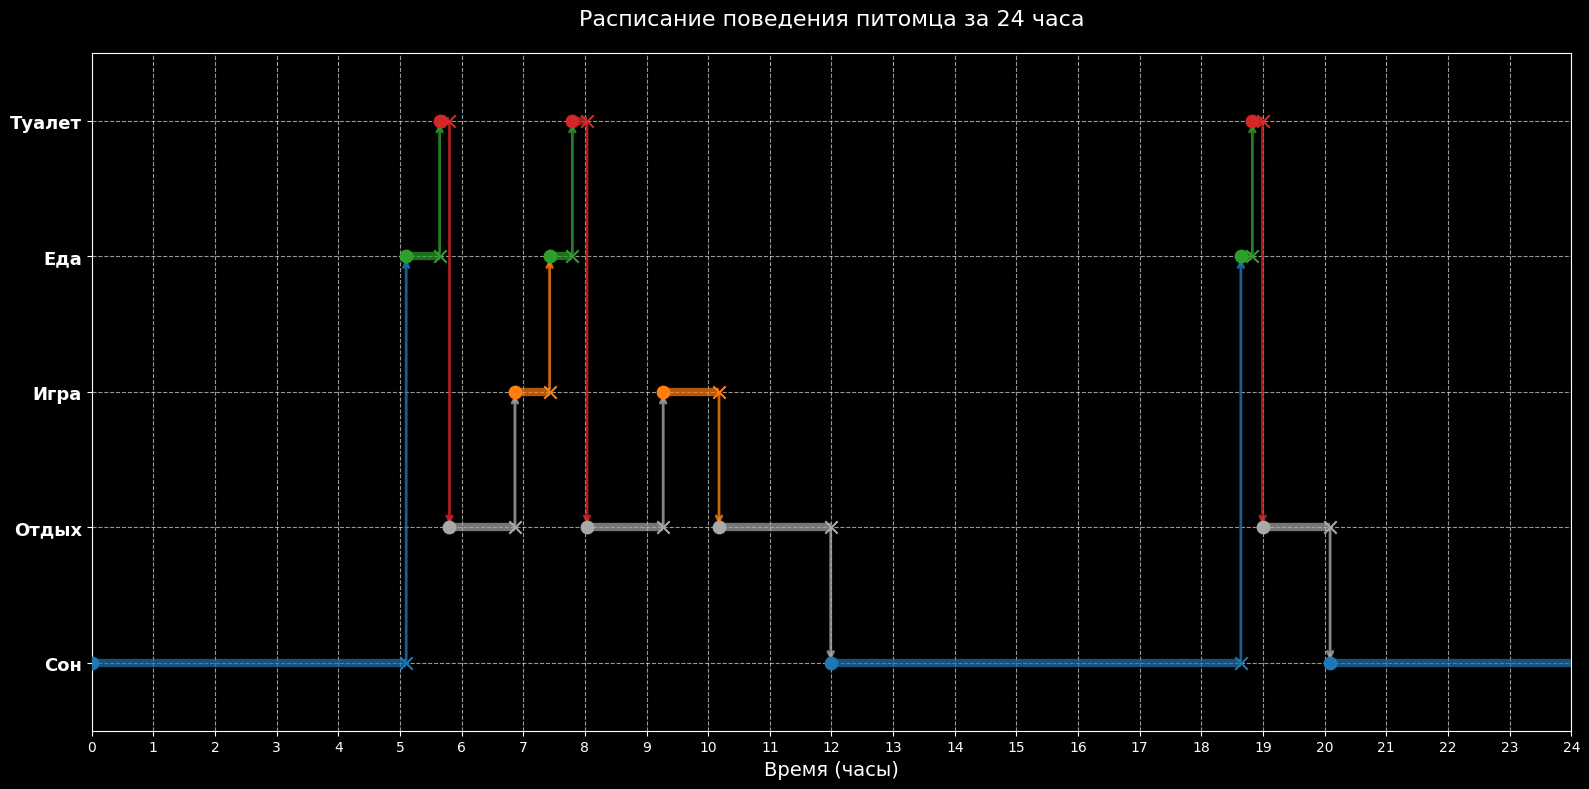

In [50]:
def draw_arrow(x1, y1_str, x2, y2_str, color):
    """Функция отрисовки стрелок (из вашего примера)"""
    plt.annotate('', xy=(x2, y_levels[y2_str]), xytext=(x1, y_levels[y1_str]),
                 arrowprops=dict(arrowstyle="->", color=color, lw=2.0, alpha=0.8))

#history_24h = simulate_pet(24)
history_24h = simulate_pet_erlang(24, K)

plt.figure(figsize=(16, 8))

for i, (start_t, end_t, state) in enumerate(history_24h):
    c = colors[state]

    # Линия нахождения в состоянии (в вашем стиле linewidth=6)
    plt.hlines(y=y_levels[state], xmin=start_t, xmax=end_t, color=c, linewidth=6, alpha=0.7)

    # Отмечаем начало состояния
    plt.scatter(start_t, y_levels[state], color=c, marker='o', s=80, zorder=5)

    # Если это не последнее состояние за 24ч, рисуем вертикальную стрелку перехода
    if i < len(history_24h) - 1:
        next_state = history_24h[i+1][2]
        # Используем цвет текущего состояния для стрелки, ведущей к следующему
        draw_arrow(end_t, state, end_t, next_state, c)
        # Отмечаем конец состояния (и начало перехода)
        plt.scatter(end_t, y_levels[state], color=c, marker='x', s=80, zorder=5)

plt.yticks(list(y_levels.values()), list(y_levels.keys()), fontsize=13, fontweight='bold')
plt.xticks(np.arange(0, 25, 1))
plt.xlabel('Время (часы)', fontsize=14)
plt.title('Расписание поведения питомца за 24 часа', fontsize=16, pad=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 24)
plt.ylim(0.5, 5.5)
plt.tight_layout()
plt.show()

### Ячейка 5. Cходимость к стационарному распределению

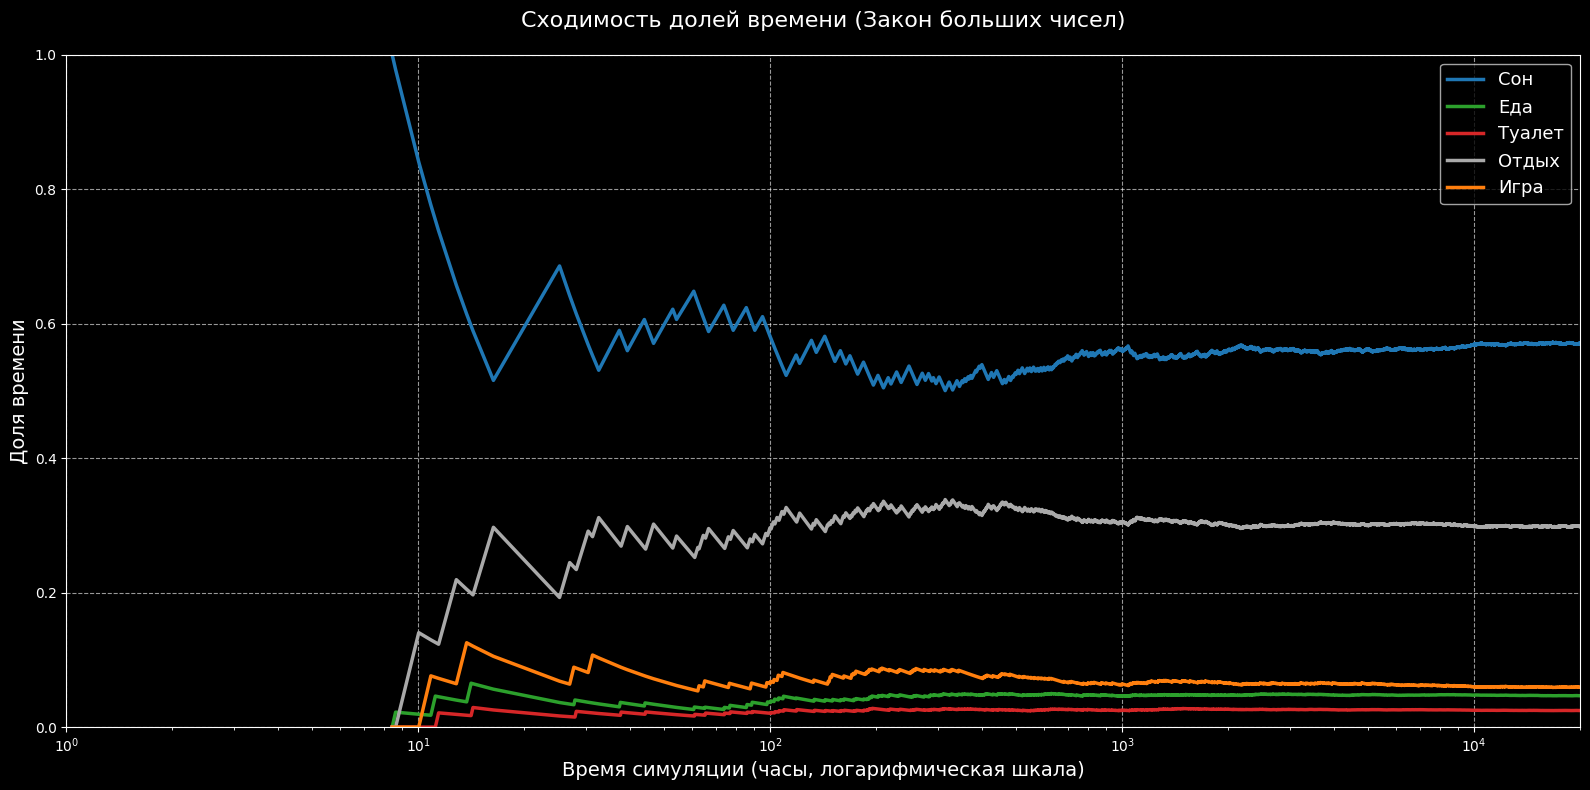

Финальное стационарное распределение (процент времени жизни питомца):
 - Сон: 57.05%
 - Еда: 4.67%
 - Туалет: 2.47%
 - Отдых: 29.84%
 - Игра: 5.96%


In [51]:
TOTAL_HOURS = 20000
history_long = simulate_pet_erlang(TOTAL_HOURS, 10)

times = []
cumulative_fractions = {state: [] for state in states}
time_spent = {state: 0.0 for state in states}

for start_t, end_t, state in history_long:
    duration = end_t - start_t
    time_spent[state] += duration
    times.append(end_t)
    for s in states:
        cumulative_fractions[s].append(time_spent[s] / end_t)

plt.figure(figsize=(16, 8))

for state in states:
    plt.plot(times, cumulative_fractions[state], label=state, color=colors[state], linewidth=2.5)

plt.xlabel('Время симуляции (часы, логарифмическая шкала)', fontsize=14)
plt.ylabel('Доля времени', fontsize=14)
plt.title('Сходимость долей времени (Закон больших чисел)', fontsize=16, pad=20)
plt.legend(loc='upper right', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xscale('log') # Логарифмическая шкала покажет сглаживание к константе
plt.xlim(1, TOTAL_HOURS)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

print("Финальное стационарное распределение (процент времени жизни питомца):")
for state in states:
    print(f" - {state}: {cumulative_fractions[state][-1]:.2%}")